In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pygraphviz as pygv

In [15]:
#H = nx.read_graphml('springRest_wdata1.gml')
H = nx.read_graphml('GL10appsDataGraphs/monolith-to-microservices.gml')
G = nx.Graph(H) # create an undirected graph G from a directed graph H

G.number_of_edges() #184
G.number_of_nodes() #102

24

In [16]:
def draw_graph(graph, title="", mylabels={}):
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2)
    plt.figure(1,figsize=(25,45))
    nx.draw(graph,
        pos = pos,
        node_color='pink',
        node_size=4000,
        labels=mylabels,
        with_labels=True,
        font_size = 16,
        font_color='black')
    plt.title(label=title, fontsize=40, color="green")
    edge_labels = dict([((n1, n2), d['rel_type'])
                    for n1, n2, d in graph.edges(data=True)])
    edge_labels
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=20, font_weight='bold')
    plt.show()

In [17]:
def DrawInitialGraph(G,gname=""):
    global DrawG
    global project
    scale = 50
    DrawG = pygv.AGraph(directed=True, strict='true', splines='true')
    
    for i in G.nodes():
        DrawG.add_node(i, shape='circle', color='blue', label=G.nodes[i]['name'])
        
    for i in G.edges():
        edge_color = 'black' if G[i[0]][i[1]]['rel_type'] in ['Calls', 'Persists', 'References'] else 'gray'
        DrawG.add_edge(i[0], i[1], color=edge_color, label=G[i[0]][i[1]]['rel_type'], fontsize='8')
    
    DrawG.layout(prog='dot')
    DrawG.draw('GL10appsDataGraphs/'+ gname +'.png')

In [7]:
DrawInitialGraph(G,"completegraph")

In [18]:

subEdges = [(u,v,d) for u,v,d in G.edges(data = True) if d['rel_type'] in ['Extends','References']]
#subG.add_edges_from(subEdges)
subEdges

[('1', '3', {'rel_type': 'References', 'weight': 0.2})]

In [9]:
subNodes = set()
for nd in subEdges:
    subNodes.add(nd[0])
    subNodes.add(nd[1])
    #print( nd[0], nd[1])    
    
#print(subNodes.sort())
subNodes = sorted(subNodes,key=int)
#print(sorted(subNodes,key=int))
#subNodes

In [10]:
subNodes

['0', '2', '3', '5', '7', '8']

In [11]:
subG = nx.Graph()
for n in G.nodes(data=True):
    if (n[0] in subNodes):
        print(f"{n}")
        #subG.add_node(n[0])
        subG.add_nodes_from([n])
        #subG.add_nodes_from(subNodes) error

('0', {'name': 'Order', 'type': 'Entity'})
('2', {'name': 'Product', 'type': 'Entity'})
('3', {'name': 'LineItem', 'type': 'Entity'})
('5', {'name': 'CartItem', 'type': 'Entity'})
('7', {'name': 'Cart', 'type': 'Entity'})
('8', {'name': 'Item', 'type': 'Entity'})


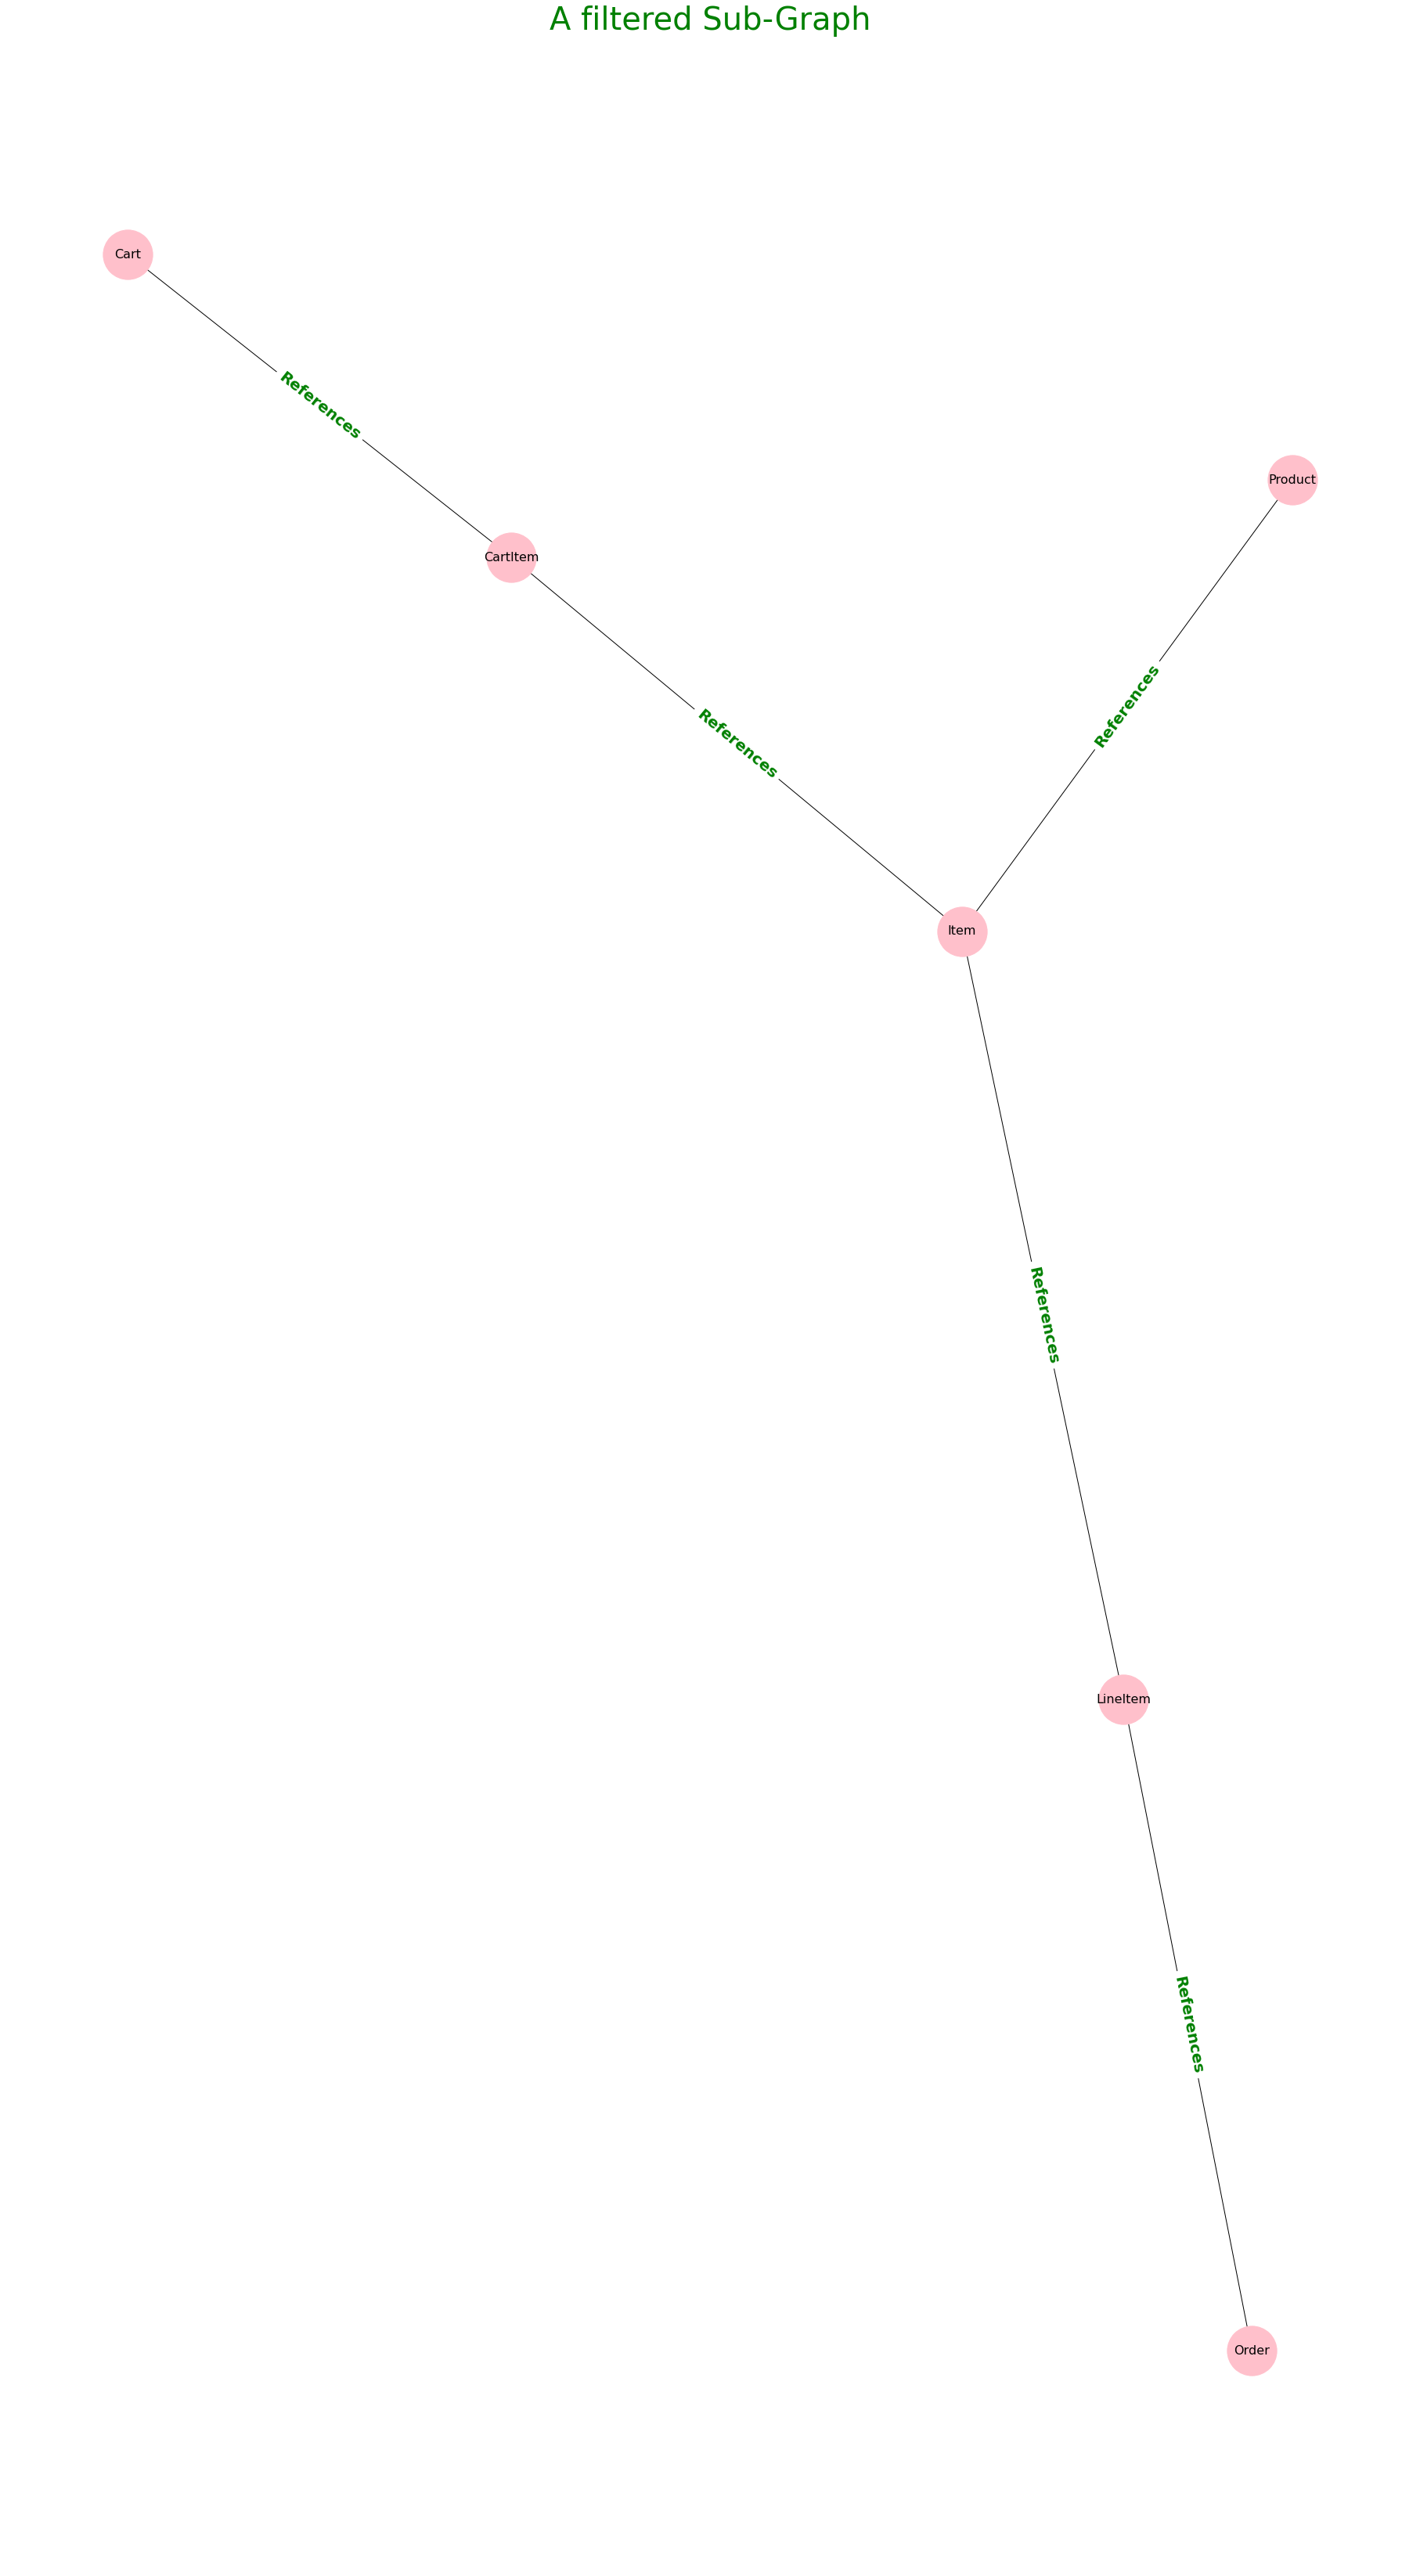

In [12]:
nodeLabeldict = {}
#nodeLabeldict = dict(subG.nodes(data=True))
#print(labeldict['41']['type'])

for i,v in subG.nodes(data=True):
    #print(i,v,v['name'])
    nodeLabeldict[i] = v['name']

subG.nodes(data=True)

subG.add_edges_from(subEdges)

draw_graph(subG,"A filtered Sub-Graph", nodeLabeldict)

In [13]:
import community as community_louvain
import matplotlib.cm as cm

# compute the best partition
partition = community_louvain.best_partition(subG)
print(partition)
#print(max(partition.values()))
#print(partition.values())
#print(partition.keys())

{k: v for k, v in sorted(partition.items(), key=lambda item: item[1])}


{'0': 2, '2': 1, '3': 2, '5': 0, '7': 0, '8': 1}


{'5': 0, '7': 0, '2': 1, '8': 1, '0': 2, '3': 2}

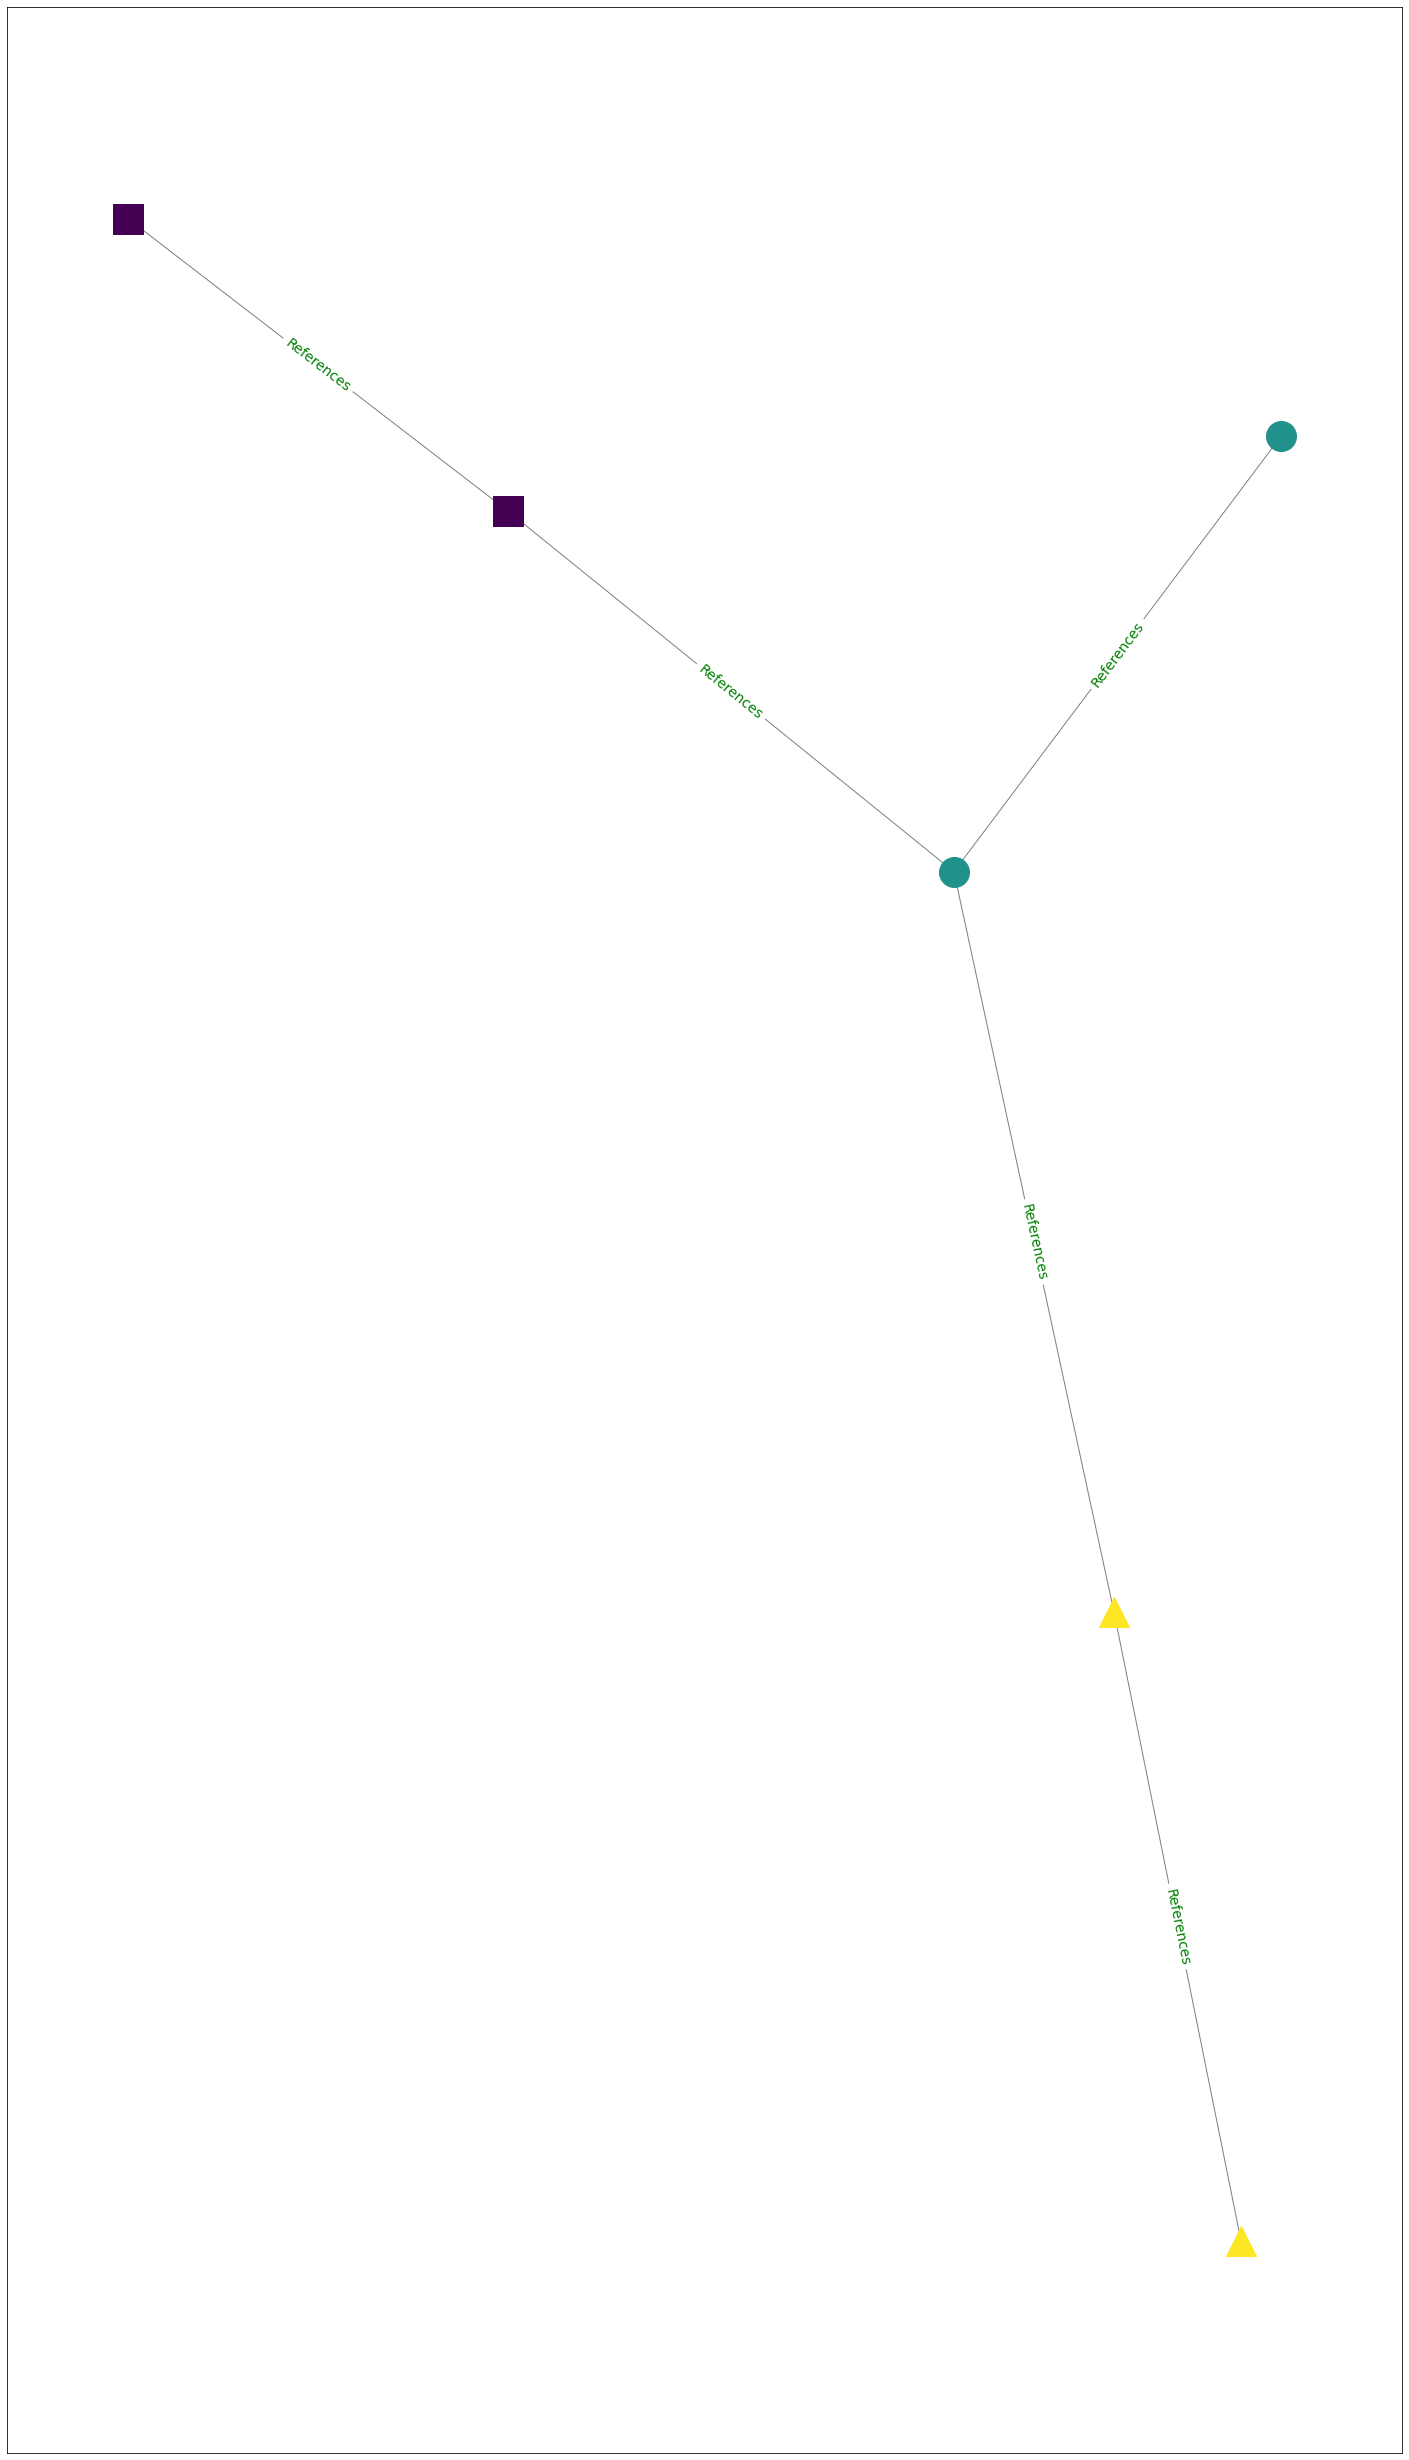

In [14]:
shapes = 'so^>v<dph8'

# draw the graph
pos = nx.spring_layout(subG, k=0.3, iterations=50, seed=2)      #pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2) 
plt.figure(1, figsize=(25,45))

# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)

edge_labels = dict([((n1, n2), d['rel_type'])
                    for n1, n2, d in subG.edges(data=True)])
edge_labels

nx.draw_networkx_edges(subG, pos, alpha=0.5)
nx.draw_networkx_edge_labels(partition, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=14, font_weight='normal')

for node, clstr in partition.items():
    nx.draw_networkx_nodes(partition, pos, [node], node_size=900,
                           node_color=[cmap.colors[clstr]],
                           node_shape=shapes[clstr])

#nx.draw(subG,
        #[node], 
 #       pos,
 #       node_color='pink',
 #       node_size=4000,
 #       labels=nodeLabeldict,
 #       with_labels=True,
 #       font_size = 10,
 #       font_color='black',
 #       font_weight='normal')
plt.show()

In [10]:
subG.number_of_nodes() #102

6

In [ ]:
list(subG.nodes.data())[0:10:None]